# Using tidy3d's Official Agent Skill: FlexAgent MCP

`tidy3d_101` and `charge_solver` showed you how to build simulations by hand. This tutorial shows a faster path: Flexcompute already ships an official AI integration for tidy3d, called **FlexAgent MCP**. It turns a coding agent into a physics-aware tidy3d assistant — no custom skill-writing required. Every command below runs for real, so you see the actual output, not a mockup.

## What is a coding agent?

A coding agent is a program that reads a prompt, writes code, runs it, reads the result, and repeats until the task is done. It lives in your terminal and edits your project files directly, instead of you copy-pasting from a chat window.

Two widely used ones:

- **Claude Code** (Anthropic) — the `claude` command
- **Codex CLI** (OpenAI) — the `codex` command

Both work the same way from a user's point of view: you type a request in plain English, the agent plans, edits files, and runs commands.

## Prerequisite: Node.js and npm

Both CLIs install through `npm`, which ships with Node.js. If the check below prints version numbers, you already have it. If it doesn't, and you already have Python, the quickest route is [nodeenv](https://github.com/ekalinin/nodeenv) — pip-installed, gives you a real Node.js + npm:

```bash
pip install nodeenv
nodeenv --prebuilt node_env
source node_env/bin/activate
```

Then re-run the cell below.

In [1]:
!node --version
!npm --version

v25.8.0
11.11.0


## Installing the agents

```bash
npm install -g @anthropic-ai/claude-code   # gives you `claude`
npm install -g @openai/codex               # gives you `codex`
```

`claude` is already on this machine. Let's install `codex` for real and confirm both.

In [2]:
!CI=true npm install -g @openai/codex --no-fund --no-audit


changed 2 packages in 3s


In [3]:
!claude --version
!codex --version

2.1.224 (Claude Code)
codex-cli 0.148.0


## What is FlexAgent MCP?

FlexAgent MCP is Flexcompute's own MCP (Model Context Protocol) server for tidy3d. Unlike a generic coding agent, it understands tidy3d's API and electromagnetic-simulation concepts directly, and it can search and fetch the real tidy3d documentation instead of guessing. It ships two ways:

- **Bundled** — inside the official Tidy3D extensions for Cursor and VS Code. Install the extension and FlexAgent is configured automatically, rules included.
- **Standalone** — as an MCP server, `tidy3d-mcp`, that you register with any MCP-compatible client, including `claude` and `codex`. That's the path this tutorial uses.

## Registering FlexAgent MCP

**Prerequisites:** the [uv](https://docs.astral.sh/uv/getting-started/installation/) package manager, and a tidy3d API key from Account Center → API key tab (same place as `tidy3d_101`, and it gets the same treatment: **never typed where it can be logged or committed**).

```bash
read -s -p "Paste your tidy3d API key: " TIDY3D_API_KEY; export TIDY3D_API_KEY
claude mcp add tidy3d -- uvx tidy3d-mcp --api-key "$TIDY3D_API_KEY"
codex mcp add tidy3d -- uvx tidy3d-mcp --api-key "$TIDY3D_API_KEY"
```

This machine already has it registered this way. Let's check the connection — redacting the key automatically, since `claude mcp list` otherwise echoes it back in plain text:

In [4]:
import subprocess, re

out = subprocess.run(["claude", "mcp", "list"], capture_output=True, text=True).stdout
out = re.sub(r"(--api-key\s+)\S+", r"\1***REDACTED***", out)
print(out.replace("\u2714", "[ok]"))

Checking MCP server health…

tidy3d: uvx tidy3d-mcp --api-key ***REDACTED*** - [ok] Connected



`[ok] Connected` means the agent can now call two extra tools: `search_flexcompute_docs` and `fetch_flexcompute_doc`. That's the whole mechanism — no skill file to write.

There's also an interactive way to check, no scripting needed: run `claude` on its own to start a session, then type `/mcp` and press Enter. It opens a status page listing every registered server, whether it's connected, and how many tools it exposes:

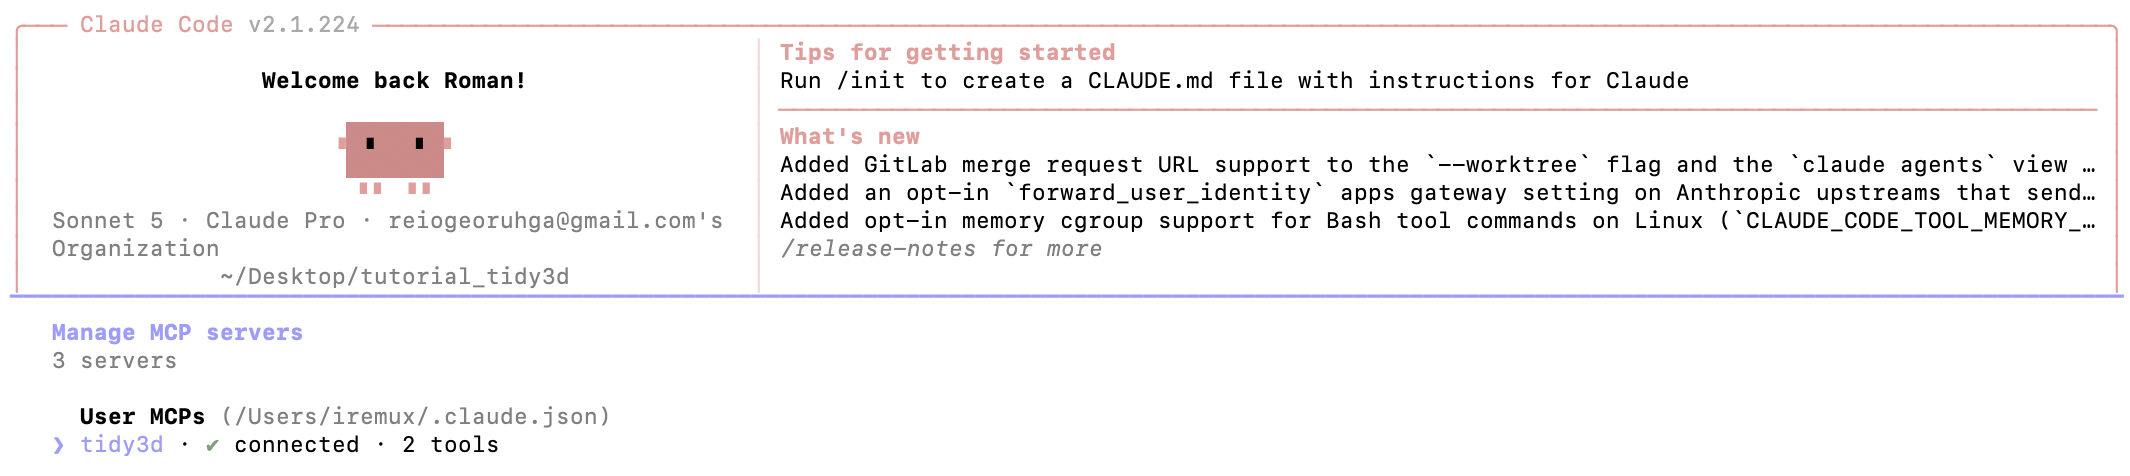

In [5]:
from IPython.display import Image, display

display(Image(filename="images/mcp_check.png"))

The `tidy3d` row shows `connected · 2 tools` — the same fact the redacted check above confirmed, just read from the UI instead of a script. Handy for a quick check mid-session, without leaving the agent.

## FlexAgent in action

Flexcompute's own docs group example prompts into five categories: Learning, Troubleshooting, Customization, Build From Scratch, and Analysis. Two real ones, run for real below.

**Learning** — ask it to explain a tidy3d concept, grounded in the real docs:

In [6]:
!claude -p "How to set up a GaussianBeam source in tidy3d? Answer in 2 sentences." --allowedTools "mcp__tidy3d__search_flexcompute_docs mcp__tidy3d__fetch_flexcompute_doc" 

In tidy3d, create a `td.GaussianBeam` by specifying `center`, `size` (a 2D plane), `direction` (`'+'` or `'-'`), `waist_radius`, `waist_distance`, `pol_angle`, and a `source_time=td.GaussianPulse(freq0=..., fwidth=...)` for the temporal profile. For example: `td.GaussianBeam(center=(0,0,0), size=(td.inf, td.inf, 0), source_time=td.GaussianPulse(freq0=2e14, fwidth=4e13), direction='+', waist_radius=1.0)`.


**Build From Scratch** — one of Flexcompute's own documented examples, verbatim:

In [7]:
!claude -p "Create a simple FDTD simulation setup to simulate a silicon strip waveguide with dimensions (0.5, 0.22, 10) and refractive index of 3.47. Print the code only, do not write to any file." --allowedTools "mcp__tidy3d__search_flexcompute_docs mcp__tidy3d__fetch_flexcompute_doc" 

Here's a simple Tidy3D FDTD setup for a silicon strip waveguide (0.5 µm × 0.22 µm × 10 µm), with silicon modeled as a lossless medium of index 3.47:

```python
import numpy as np
import tidy3d as td

# --- Waveguide geometry (um) ---
wg_width = 0.5
wg_height = 0.22
wg_length = 10.0

# --- Materials ---
n_si = 3.47
si = td.Medium(permittivity=n_si**2, name="Si")
sio2 = td.Medium(permittivity=1.44**2, name="SiO2")  # oxide cladding/substrate

# --- Wavelength / frequency setup ---
wavelength = 1.55
freq0 = td.C_0 / wavelength
fwidth = freq0 / 10
run_time = 5e-13

# --- Structures ---
waveguide = td.Structure(
    geometry=td.Box(
        center=(0, 0, 0),
        size=(wg_length, wg_width, wg_height),
    ),
    medium=si,
)

# --- Source: mode source injecting the fundamental TE mode ---
mode_spec = td.ModeSpec(num_modes=1, target_neff=n_si)

source = td.ModeSource(
    center=(-wg_length / 2 + 1, 0, 0),
    size=(0, 3 * wg_width, 3 * wg_height),
    source_time=td.GaussianPulse(freq0=f

Both answers came from the real `tidy3d-mcp` server, not from the model's own (possibly outdated) memory of the API — that's the point of registering it.

## One step further: superskills

FlexAgent covers tidy3d itself. For everything else an agent does day to day — planning, code review, debugging — **superskills** is a ready-made collection of general-purpose skills you install alongside it. A reasonable default: FlexAgent for tidy3d domain knowledge, superskills for general workflow.